In [9]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy import stats
import seaborn as sns
import rasterio
from pyproj import Transformer
import pyogrio
from pathlib import Path

In [4]:
fechas_amatitlan = [
    "2025-01-28",
    "2025-04-15",
    "2025-04-28",
    "2025-11-24",
    "2026-01-08",
    "2026-02-02",
    "2026-02-07",
    "2026-03-29",
    "2026-04-13",
    "2026-04-28",
    "2026-06-19"
]

fechas_atitlan = [
    "2025-01-18",
    "2025-04-13",
    "2025-05-13",
    "2025-07-17",
    "2025-11-21",
    "2025-12-29",
    "2026-02-12",
    "2026-03-24",
    "2026-04-13",
    "2026-04-28",
    "2026-07-22"
]

In [5]:
#La siguiente función devuelve el promedio de la cianobaccteria y es la misma función del inciso 4
def promedio_cianobacteria(ruta_raster):

    with rasterio.open(ruta_raster) as src:
        
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

        data[~np.isfinite(data)] = np.nan
        promedio = np.nanmean(data)

    return promedio

#LA siguiente realiza el procesamiento en todas las fechas; es la misma función del inciso 4
def procesar_lago(nombre_lago, carpeta, fechas, nombre):
    resultados = []

    for fecha in fechas:
        ruta = Path(carpeta) / f"{nombre}_{fecha}_indices.tif"

        promedio = promedio_cianobacteria(ruta)

        resultados.append({
            "lago": nombre_lago,
            "fecha": fecha,
            "cyano_promedio": promedio
        })
        
    return pd.DataFrame(resultados)

In [10]:
#Se procceden a crear dataframes con el índice promedio, es parte del proceso usado en el inciso 4
df_amatitlan = procesar_lago(nombre_lago="Amatitlán", carpeta="data/processed/amatitlan", fechas=fechas_amatitlan, nombre='amatitlan')
df_atitlan = procesar_lago(nombre_lago="Atitlán", carpeta="data/processed/atitlan", fechas=fechas_atitlan, nombre='atitlan')

df = pd.concat([df_amatitlan, df_atitlan], ignore_index=True)
df["fecha"] = pd.to_datetime(df["fecha"])

In [11]:
df_amatitlan

,lago,fecha,cyano_promedio
0,Amatitlán,2025-01-28,4.428946
1,Amatitlán,2025-04-15,4.528544
2,Amatitlán,2025-04-28,4.255442
3,Amatitlán,2025-11-24,5.468830
4,Amatitlán,2026-01-08,6.688481
5,Amatitlán,2026-02-02,4.287532
6,Amatitlán,2026-02-07,4.302523
7,Amatitlán,2026-03-29,6.431256
8,Amatitlán,2026-04-13,6.738171
9,Amatitlán,2026-04-28,10.026723


In [12]:
df_atitlan

,lago,fecha,cyano_promedio
0,Atitlán,2025-01-18,0.386553
1,Atitlán,2025-04-13,1.783338
2,Atitlán,2025-05-13,1.293994
3,Atitlán,2025-07-17,0.820357
4,Atitlán,2025-11-21,0.271335
5,Atitlán,2025-12-29,0.534299
6,Atitlán,2026-02-12,0.916540
7,Atitlán,2026-03-24,1.265022
8,Atitlán,2026-04-13,2.128609
9,Atitlán,2026-04-28,1.855590


In [14]:
#Se transforman a datetime las fechas de los dataframes anteriores
df_amatitlan["fecha"] = pd.to_datetime(df_amatitlan["fecha"])
df_atitlan["fecha"] = pd.to_datetime(df_atitlan["fecha"])

df_amatitlan = df_amatitlan.sort_values("fecha")
df_atitlan = df_atitlan.sort_values("fecha")

# 7.1. Análisis de la proliferación de la ciano bacteria en el período establecido en los dos lagos 

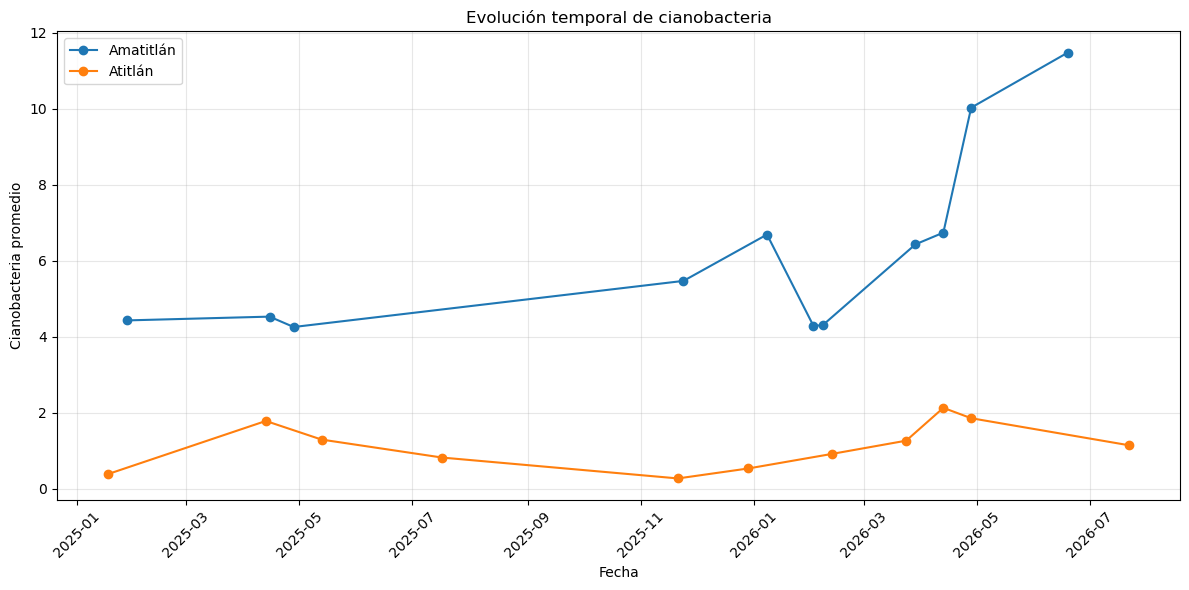

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    df_amatitlan["fecha"],
    df_amatitlan["cyano_promedio"],
    marker="o",
    label="Amatitlán"
)

plt.plot(
    df_atitlan["fecha"],
    df_atitlan["cyano_promedio"],
    marker="o",
    label="Atitlán"
)

plt.xlabel("Fecha")
plt.ylabel("Cianobacteria promedio")
plt.title("Evolución temporal de cianobacteria")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Se muestra en la imagen anterior que en el lago de Amatitlán hay una mayor prescencia de cianobacteria en todo el período establecidos, sin coincidencia alguna. También puede observarse cierta periodicidad en el lago de Atitlán, alcanzando sus puntos máximos entre marzo y mayo del año 2025 y marzo y mayo del año 2026. De lo anterior también se tiene que el lago de Amatitlán presenta cierta tendencia creciente, sin fuertes insicios de que llegará a reducirse. 

In [16]:
print("AMATITLÁN")
print(df_amatitlan["cyano_promedio"].describe())

print("\nATITLÁN")
print(df_atitlan["cyano_promedio"].describe())

AMATITLÁN
count    11.000000
mean      6.239205
std       2.460415
min       4.255442
25%       4.365734
50%       5.468830
75%       6.713326
max      11.474802
Name: cyano_promedio, dtype: float64

ATITLÁN
count    11.000000
mean      1.127258
std       0.614989
min       0.271335
25%       0.677328
50%       1.144206
75%       1.538666
max       2.128609
Name: cyano_promedio, dtype: float64


Se observa de que en promedio, el lago de Amatitlán presenta mayores índices de cianobacteria durante el lapso escogido siendo este primero de 6.24 frente al 1.13 del lago de Atitlán. Esto también se ve reflejado en los valores máximos y mínimos de los datos, ya que el lago de Amatitlán presenta un máximmo bastante elevado frente al de Atitlán -11.47 de Amatitlán y 2.13 de Atitlán-. En cuanto a mínimos, el lago de Atitlán tiene los más bajos (0.27) frente al de Amatitlán (4.26).

# 7.2. Intensidad y frecuencia en la floración de cianobacteria en ambos lagos

In [23]:
#La siguiente función clasifica el "riesgo" -como se define en ciertos artículos relacionados- de las concentraciones de cianobacteria
#Siendo un riesgo alto aquel en donde las concentraciones se consideran altas. Más información de esto se describirá después.

#chla:= clorofila-a (dato ya incluido en las imagénes analizadas)
# esta función clasifica como: Riesgo Bajo=0, Riesgo Moderado=1, Riesgo Alto=2
def clasificar_riesgo(chla):

    riesgo = np.full(chla.shape,-1,dtype=np.int8)

    # Bajo
    riesgo[chla < 10] = 0

    # Moderado
    riesgo[(chla >= 10) &(chla <= 50)] = 1

    # Alto
    riesgo[chla > 50] = 2

    return riesgo

#Se obtienen las bandas a usar para el análisis por medio de la siguiente función.
def leer_indices(ruta):

    with rasterio.open(ruta) as src:

        chla = src.read(1).astype(float)
        ndvi = src.read(2).astype(float)
        ndwi = src.read(3).astype(float)
        valid_mask = src.read(4)

        # Solo observaciones válidas
        validos = (
            (valid_mask == 1) &
            np.isfinite(chla) &
            np.isfinite(ndvi) &
            np.isfinite(ndwi)
        )

        chla[~validos] = np.nan
        ndvi[~validos] = np.nan
        ndwi[~validos] = np.nan

    return chla, ndvi, ndwi, valid_mask

#En la siguiente función se hace uso de las anteriores para el análisis de la floración de cianobacteria solicitada
def analizar_floracion(ruta):

    chla, ndvi, ndwi, valid_mask = leer_indices(ruta)

    validos = np.isfinite(chla)

    n = validos.sum()

    bajo = (
        validos &
        (chla < 10)
    )

    moderado = (
        validos &
        (chla >= 10) &
        (chla <= 50)
    )

    alto = (
        validos &
        (chla > 50)
    )

    proliferacion = (
        validos &
        (chla >= 10)
    )

    return {

        # Intensidad
        "chla_promedio":
            np.nanmean(chla),

        "chla_mediana":
            np.nanmedian(chla),

        "chla_maximo":
            np.nanmax(chla),

        # Extensión por categoría
        "porcentaje_bajo":
            100 * bajo.sum() / n,

        "porcentaje_moderado":
            100 * moderado.sum() / n,

        "porcentaje_alto":
            100 * alto.sum() / n,

        # Extensión total de proliferación
        "porcentaje_proliferacion":
            100 * proliferacion.sum() / n,

        # Índices
        "ndvi_promedio":
            np.nanmean(ndvi),

        "ndwi_promedio":
            np.nanmean(ndwi)
    }

#La siguiente función es para aplicar a todos los archivos el análisis antes hecho
def aplicar_floracion(nombre_lago, carpeta, fechas, nombre):

    resultados = []

    for fecha in fechas:

        ruta = (
            Path(carpeta) /
            f"{nombre}_{fecha}_indices.tif"
        )

        analisis = analizar_floracion(ruta)

        analisis["lago"] = nombre_lago
        analisis["fecha"] = pd.to_datetime(fecha)

        resultados.append(analisis)

    return pd.DataFrame(resultados)



In [24]:
#Se implementan los dataframes con los respectivos análisis de las funciones anteriores.
df_amatitlan = aplicar_floracion(
    "Amatitlán",
    "data/processed/amatitlan",
    fechas_amatitlan,
    "amatitlan"
)

df_atitlan = aplicar_floracion(
    "Atitlán",
    "data/processed/atitlan",
    fechas_atitlan,
    "atitlan"
)

In [26]:
UMBRAL_AREA = 10 #Umbral de >=10, ya que en entornos estables la floración no es excesiva para llegar a considerarse superior al 50% como umbral
#Además que es en 10% donde se inician las señales a simple vista de la proliferación de cianobacteria sin resultar excesiva, como se ha dicho.

df_amatitlan["evento_floracion"] = (
    df_amatitlan["porcentaje_proliferacion"]
    >= UMBRAL_AREA
)

df_atitlan["evento_floracion"] = (
    df_atitlan["porcentaje_proliferacion"]
    >= UMBRAL_AREA
)

In [28]:
#Porcentajes de fechas consideradas en las que hubo proliferacion relevante
frecuencia_amatitlan = (
    df_amatitlan["evento_floracion"].mean()
    * 100
)

frecuencia_atitlan = (
    df_atitlan["evento_floracion"].mean()
    * 100
)

In [33]:
df_amatitlan

,chla_promedio,chla_mediana,chla_maximo,porcentaje_bajo,porcentaje_moderado,porcentaje_alto,porcentaje_proliferacion,ndvi_promedio,ndwi_promedio,lago,fecha,evento_floracion
0,4.428946,4.491106,21.600559,99.967476,0.032524,0.000000,0.032524,-0.223535,0.460359,Amatitlán,2025-01-28,False
1,4.528544,4.584526,21.943108,99.328270,0.671730,0.000000,0.671730,-0.103234,0.293362,Amatitlán,2025-04-15,False
2,4.255442,4.108671,26.571762,98.762311,1.237689,0.000000,1.237689,-0.150284,0.365127,Amatitlán,2025-04-28,False
3,5.468830,4.378140,115.434052,96.143061,3.031586,0.825353,3.856939,-0.194541,0.421901,Amatitlán,2025-11-24,False
4,6.688481,4.892783,131.243958,92.886157,6.046902,1.066941,7.113843,-0.103710,0.355152,Amatitlán,2026-01-08,False
5,4.287532,4.394763,14.016261,99.994476,0.005524,0.000000,0.005524,-0.105663,0.292144,Amatitlán,2026-02-02,False
6,4.302523,4.453448,15.427299,99.972820,0.027180,0.000000,0.027180,-0.146553,0.363693,Amatitlán,2026-02-07,False
7,6.431256,5.241989,49.387218,92.389213,7.610787,0.000000,7.610787,-0.097249,0.317836,Amatitlán,2026-03-29,False
8,6.738171,6.393300,28.158697,95.527907,4.472093,0.000000,4.472093,-0.065481,0.296218,Amatitlán,2026-04-13,False
9,10.026723,6.709498,46.144222,63.561930,36.438070,0.000000,36.438070,0.021323,0.229211,Amatitlán,2026-04-28,True


In [34]:
df_atitlan

,chla_promedio,chla_mediana,chla_maximo,porcentaje_bajo,porcentaje_moderado,porcentaje_alto,porcentaje_proliferacion,ndvi_promedio,ndwi_promedio,lago,fecha,evento_floracion
0,0.386553,0.427217,30.662933,99.958901,0.041099,0.000000,0.041099,-0.269996,0.562064,Atitlán,2025-01-18,False
1,1.783338,1.775290,23.673519,99.998375,0.001625,0.000000,0.001625,-0.174771,0.431730,Atitlán,2025-04-13,False
2,1.293994,1.308052,13.703753,99.997725,0.002275,0.000000,0.002275,-0.181463,0.433657,Atitlán,2025-05-13,False
3,0.820357,1.440671,84.132812,99.904394,0.087639,0.007967,0.095606,-0.137707,0.417398,Atitlán,2025-07-17,False
4,0.271335,0.327624,27.198830,99.935217,0.064783,0.000000,0.064783,-0.266476,0.562540,Atitlán,2025-11-21,False
5,0.534299,0.534274,26.949406,99.966840,0.033160,0.000000,0.033160,-0.234692,0.511367,Atitlán,2025-12-29,False
6,0.916540,0.929990,21.310286,99.982494,0.017506,0.000000,0.017506,-0.250277,0.521314,Atitlán,2026-02-12,False
7,1.265022,1.278947,13.537392,99.998375,0.001625,0.000000,0.001625,-0.227897,0.480279,Atitlán,2026-03-24,False
8,2.128609,2.224082,15.917075,99.996417,0.003583,0.000000,0.003583,-0.160282,0.384144,Atitlán,2026-04-13,False
9,1.855590,1.895228,10.826420,99.999348,0.000652,0.000000,0.000652,-0.168183,0.395089,Atitlán,2026-04-28,False


In [31]:
#Comparación de los dos lagos
comparacion = pd.DataFrame({

    "Lago": [
        "Amatitlán",
        "Atitlán"
    ],

    "Chl-a promedio": [
        df_amatitlan["chla_promedio"].mean(),
        df_atitlan["chla_promedio"].mean()
    ],

    "% superficie en proliferación": [
        df_amatitlan[
            "porcentaje_proliferacion"
        ].mean(),

        df_atitlan[
            "porcentaje_proliferacion"
        ].mean()
    ],

    "% superficie alto riesgo": [
        df_amatitlan[
            "porcentaje_alto"
        ].mean(),

        df_atitlan[
            "porcentaje_alto"
        ].mean()
    ],

    "% fechas con floración": [
        frecuencia_amatitlan,
        frecuencia_atitlan
    ]
})
comparacion

,Lago,Chl-a promedio,% superficie en proliferación,% superficie alto riesgo,% fechas con floración
0,Amatitlán,6.239205,10.468147,0.189754,18.181818
1,Atitlán,1.127258,0.033809,0.000724,0.000000


Se puede observar a raíz del análisis anterior que el lago de Amatitlán tiene considerablemente mayores niveles de proliferación de cianobacteria, así como una mayor frecuencia en la floración de la misma como se observa en **%fechas con floración**; aunque en este mismo valor el lago de Atitlán aparezca en 0, es posible observar en **df_atitlan** que los valores suelen ser bajos en comparación con el lago de Amatitlán, además que los porccentajes de floración moderada y baja son más significativos en Atitlán que en Amatitlán.

Es importante recalcar que con el fin de mantener consistencia con los valores WHO históricos, que han sido adoptados como referencia en este análisis, se clasificó **Chl-a** en $<10$, $10–50$ y $>50 µg/L$, bajo el supuesto de dominancia de cianobacterias. Asimsimo, el umbral $>=10$, se ha establecido de esta manera ya que es, según algunos articulos referenciados al final de este documento, donde se inician las señales significativas, que pueden ser observadas a simple vista, de la proliferación de cianobacteria sin resultar excesiva.